In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm import tqdm

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
The number of trainable parameters in the model is 437532


Epoch 60/60: 100%|██████████| 235/235 [00:19<00:00, 12.14it/s, loss=0.0282]


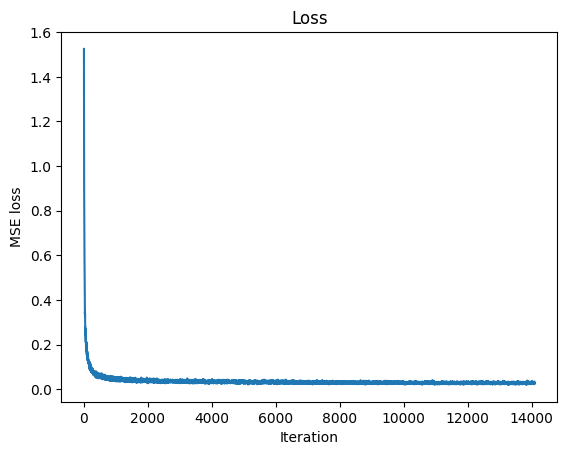

100%|██████████| 1000/1000 [02:46<00:00,  6.01it/s]


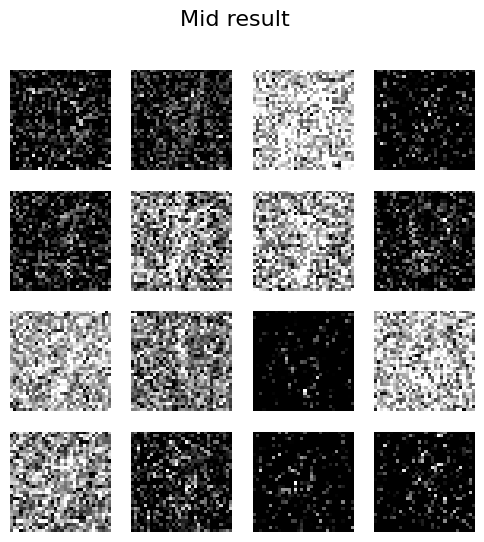

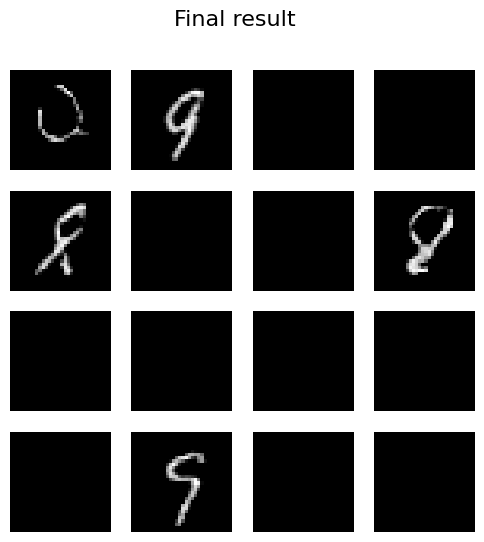

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = 32
CHANNELS = 1
NUM_TIMESTEPS = 1000
BETA_START = 0.0001
BETA_END = 0.02
LEARNING_RATE = 1e-3
NUM_EPOCHS = 60
BATCH_SIZE = 256
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


def sinusoidal_embedding(n, d):
    positions = np.arange(n)[:, None].astype(np.float32)
    div_term = np.exp(np.arange(0, d, 2) * -(math.log(10000.0) / d)).astype(np.float32)
    emb = np.zeros((n, d), dtype=np.float32)
    emb[:, 0::2] = np.sin(positions * div_term)
    emb[:, 1::2] = np.cos(positions * div_term)
    return emb


def convnet_block(in_channels, out_channels, kernel_size=3, activation='swish', normalize=True):
    seq = keras.Sequential()
    if normalize:
        seq.add(layers.LayerNormalization(axis=[1,2,3]))
    seq.add(layers.Conv2D(out_channels, kernel_size, padding='same'))
    if activation == 'swish':
        seq.add(layers.Activation(tf.nn.silu))
    else:
        seq.add(layers.Activation(activation))
    return seq

def convolution_block(image_size, in_channels, out_channels):
    return keras.Sequential([
        convnet_block(in_channels, out_channels),
        convnet_block(out_channels, out_channels),
        convnet_block(out_channels, out_channels),
    ])

def tiny_upsampling_block(image_size, in_channels):
    # in_channels here is total channels entering; we reduce gradually
    c1 = max(in_channels // 2, 1)
    c2 = max(in_channels // 4, 1)
    return keras.Sequential([
        convnet_block(in_channels, c1),
        convnet_block(c1, c2),
        convnet_block(c2, c2),
    ])

# Tiny U-Net
class TinyUNet(keras.Model):
    def __init__(self, input_channels=1, output_channels=1, size=32, num_steps=NUM_TIMESTEPS, time_emb_dim=100):
        super().__init__()
        self.size = size
        self.time_emb_dim = time_emb_dim

        # Embedding table (non-trainable) for timesteps (sinusoidal)
        emb_weights = sinusoidal_embedding(num_steps, time_emb_dim)
        self.time_embedding_table = tf.constant(emb_weights)  # shape (num_steps, time_emb_dim)

        # time embedding projector (dense stacks)
        def time_mlp(out_dim):
            return keras.Sequential([
                layers.Dense(out_dim),
                layers.Activation(tf.nn.silu),
                layers.Dense(out_dim)
            ])

        # First half
        self.time_embed_1 = time_mlp(1)
        self.conv_block_1 = convolution_block(size, input_channels, 10)
        self.downsampling_1 = layers.Conv2D(10, 4, strides=2, padding='same')

        self.time_embed_2 = time_mlp(10)
        self.conv_block_2 = convolution_block(size//2, 10, 20)
        self.downsampling_2 = layers.Conv2D(20, 4, strides=2, padding='same')

        self.time_embed_3 = time_mlp(20)
        self.conv_block_3 = convolution_block(size//4, 20, 40)
        self.downsampling_3 = layers.Conv2D(40, 4, strides=2, padding='same')

        # Bottleneck
        self.time_embed_mid = time_mlp(40)
        self.bottleneck = keras.Sequential([
            convnet_block(40, 20),
            convnet_block(20, 20),
            convnet_block(20, 40),
        ])

        # Second half
        self.upsampling_1 = layers.Conv2DTranspose(40, 4, strides=2, padding='same')
        self.time_embed_4 = time_mlp(80)
        self.upsampling_block_1 = tiny_upsampling_block(size//4, 80)

        self.upsampling_2 = layers.Conv2DTranspose(20, 4, strides=2, padding='same')
        self.time_embed_5 = time_mlp(40)
        self.upsampling_block_2 = tiny_upsampling_block(size//2, 40)

        self.upsampling_3 = layers.Conv2DTranspose(10, 4, strides=2, padding='same')
        self.time_embed_out = time_mlp(20)
        self.conv_block_out = convolution_block(size, 20, 10)
        self.output_conv = layers.Conv2D(output_channels, 3, padding='same')

    def call(self, x, t):
        """
        x: tensor shape (batch, H, W, C)
        t: integer tensor shape (batch,) with timestep indices
        """
        # get sinusoidal embedding vectors for the batch timesteps
        t_emb = tf.gather(self.time_embedding_table, t)  # (batch, time_emb_dim)

        n = tf.shape(x)[0]

        # apply time embeddings after projecting and reshaping to match channels
        te1 = self.time_embed_1(t_emb)  # (batch, 1)
        te1 = tf.reshape(te1, (n, 1, 1, -1))
        out1 = self.conv_block_1(x + te1)

        ds1 = self.downsampling_1(out1)
        te2 = self.time_embed_2(t_emb)
        te2 = tf.reshape(te2, (n,1,1,-1))
        out2 = self.conv_block_2(ds1 + te2)

        ds2 = self.downsampling_2(out2)
        te3 = self.time_embed_3(t_emb)
        te3 = tf.reshape(te3, (n,1,1,-1))
        out3 = self.conv_block_3(ds2 + te3)

        ds3 = self.downsampling_3(out3)
        temid = tf.reshape(self.time_embed_mid(t_emb), (n,1,1,-1))
        out_mid = self.bottleneck(ds3 + temid)

        up1 = self.upsampling_1(out_mid)
        # concat skip with out3 along channels
        out4 = tf.concat([out3, up1], axis=-1)
        te4 = tf.reshape(self.time_embed_4(t_emb), (n,1,1,-1))
        out4 = self.upsampling_block_1(out4 + te4)

        up2 = self.upsampling_2(out4)
        out5 = tf.concat([out2, up2], axis=-1)
        te5 = tf.reshape(self.time_embed_5(t_emb), (n,1,1,-1))
        out5 = self.upsampling_block_2(out5 + te5)

        up3 = self.upsampling_3(out5)
        out = tf.concat([out1, up3], axis=-1)
        te_out = tf.reshape(self.time_embed_out(t_emb), (n,1,1,-1))
        out = self.conv_block_out(out + te_out)
        out = self.output_conv(out)
        return out  # returns predicted noise (epsilon)

# DDPM wrapper
class DDPM:
    def __init__(self, network, num_timesteps=NUM_TIMESTEPS, beta_start=BETA_START, beta_end=BETA_END):
        self.network = network
        self.num_timesteps = num_timesteps
        # betas linearly spaced
        self.betas = tf.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = tf.math.cumprod(self.alphas, axis=0)
        # precompute sqrt arrays
        self.sqrt_alphas_cumprod = tf.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = tf.sqrt(1.0 - self.alphas_cumprod)

    def add_noise(self, x_start, noise, timesteps):
        """
        x_start: (B,H,W,C) in original image range (we'll keep normalized floats)
        noise: same shape gaussian
        timesteps: (B,) integer indices
        """
        s1 = tf.gather(self.sqrt_alphas_cumprod, timesteps)
        s2 = tf.gather(self.sqrt_one_minus_alphas_cumprod, timesteps)
        s1 = tf.reshape(s1, (-1,1,1,1))
        s2 = tf.reshape(s2, (-1,1,1,1))
        return s1 * x_start + s2 * noise

    def reverse(self, x, t):
        # network predicts noise epsilon
        return self.network(x, t)

    def step(self, model_output, timestep, sample):
        """
        model_output: predicted noise (batch,H,W,C)
        timestep: scalar int (we will allow a scalar or 0-D tensor)
        sample: current sample x_t (batch,H,W,C)
        returns x_{t-1}
        """
        t = int(timestep)  # convert to python int
        # coefficients (vectorized but we only use t index)
        coef_epsilon = (1.0 - self.alphas) / tf.sqrt(1.0 - self.alphas_cumprod)  # shape (T,)
        coef_eps_t = coef_epsilon[t]
        coef_first = 1.0 / tf.sqrt(self.alphas)
        coef_first_t = coef_first[t]

        pred_prev = coef_first_t * (sample - coef_eps_t * model_output)
        if t > 0:
            noise = tf.random.normal(tf.shape(sample))
            variance = tf.sqrt(self.betas[t]) * noise
            pred_prev = pred_prev + variance
        return pred_prev


def load_mnist_dataset(batch_size=BATCH_SIZE, img_size=IMG_SIZE):
    (x_train, _), (_, _) = keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    # Normalize using same mean/std as PyTorch MNIST normalize((0.1307,), (0.3081,))
    mean = 0.1307
    std = 0.3081
    x_train = (x_train - mean) / std
    x_train = np.expand_dims(x_train, -1)  # (N,28,28,1)
    # Resize to IMG_SIZE
    x_train = tf.image.resize(x_train, [img_size, img_size]).numpy()
    ds = tf.data.Dataset.from_tensor_slices(x_train)
    ds = ds.shuffle(1024).batch(batch_size).prefetch(AUTOTUNE)
    return ds


@tf.function
def train_step(model_ddpm: DDPM, optimizer, batch):
    batch_size = tf.shape(batch)[0]
    noise = tf.random.normal(tf.shape(batch))
    timesteps = tf.random.uniform((batch_size,), minval=0, maxval=model_ddpm.num_timesteps, dtype=tf.int32)
    noisy = model_ddpm.add_noise(batch, noise, timesteps)

    with tf.GradientTape() as tape:
        pred_noise = model_ddpm.reverse(noisy, timesteps)
        loss = tf.reduce_mean(tf.square(pred_noise - noise))

    # compute grads & apply to network.trainable_variables
    grads = tape.gradient(loss, model_ddpm.network.trainable_variables)
    optimizer.apply_gradients(zip(grads, model_ddpm.network.trainable_variables))
    return loss

def training_loop(model_ddpm: DDPM, dataset, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    losses = []
    for epoch in range(num_epochs):
        pbar = tqdm(dataset, desc=f"Epoch {epoch+1}/{num_epochs}")
        epoch_losses = []
        for batch in pbar:
            # batch is (B,H,W,1)
            loss = train_step(model_ddpm, optimizer, batch)
            epoch_losses.append(float(loss))
            pbar.set_postfix({"loss": float(loss)})
        losses += epoch_losses
    return losses


def generate_images(ddpm: DDPM, sample_size=16, channel=CHANNELS, size=IMG_SIZE):
    frames = []
    frames_mid = []
    sample = tf.random.normal((sample_size, size, size, channel))
    # iterate timesteps in reverse
    timesteps = list(range(ddpm.num_timesteps-1, -1, -1))
    for t in tqdm(timesteps):
        # create a tensor of timestep indices for the batch
        time_tensor = tf.fill([sample_size], t)
        residual = ddpm.reverse(sample, time_tensor)  # predicted noise
        sample = ddpm.step(residual, t, sample)
        if t == ddpm.num_timesteps // 2:
            frames_mid = [sample[i].numpy() for i in range(sample_size)]
    frames = [sample[i].numpy() for i in range(sample_size)]
    return frames, frames_mid


def show_images_tf(images, title="", n_display=16):
    imgs = images[:n_display]
    n = len(imgs)
    cols = int(math.sqrt(n))
    rows = math.ceil(n / cols)
    plt.figure(figsize=(6,6))
    plt.suptitle(title, fontsize=16)
    for i, im in enumerate(imgs):
        ax = plt.subplot(rows, cols, i+1)
        # undo normalization to display (approx): x = im*std + mean
        mean = 0.1307; std = 0.3081
        im_disp = im.squeeze() * std + mean
        im_disp = np.clip(im_disp, 0.0, 1.0)
        ax.imshow(im_disp, cmap='gray')
        ax.axis('off')
    plt.show()

# Execution
if __name__ == "__main__":
    ds = load_mnist_dataset(batch_size=BATCH_SIZE, img_size=IMG_SIZE)

    network = TinyUNet(input_channels=CHANNELS, output_channels=CHANNELS, size=IMG_SIZE, num_steps=NUM_TIMESTEPS, time_emb_dim=100)

    dummy_x = tf.zeros((1, IMG_SIZE, IMG_SIZE, CHANNELS))
    dummy_t = tf.constant([0], dtype=tf.int32)
    _ = network(dummy_x, dummy_t)

    model_ddpm = DDPM(network, num_timesteps=NUM_TIMESTEPS, beta_start=BETA_START, beta_end=BETA_END)

    # Number of parameters
    total_params = np.sum([np.prod(v.shape) for v in network.trainable_variables])
    print(f"The number of trainable parameters in the model is {total_params}")

    # Train
    losses = training_loop(model_ddpm, ds, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE)

    # loss
    plt.plot(losses)
    plt.title("Loss")
    plt.xlabel("Iteration")
    plt.ylabel("MSE loss")
    plt.show()

    # ِDisplay
    generated, generated_mid = generate_images(model_ddpm, sample_size=16, channel=CHANNELS, size=IMG_SIZE)
    if len(generated_mid) > 0:
        show_images_tf(generated_mid, "Mid result", n_display=min(16,len(generated_mid)))
    show_images_tf(generated, "Final result", n_display=16)
